# 🎓 Exam Cheating Dataset — EDA
**Dataset:** ExamCheatingDataset (Kaggle)  
**Classes:** cheating · giving code · giving object · looking friend · normal act  
**Total files:** ~2058 images across train/test splits

## 1. Prerequisites

Place the unzipped **ExamCheatingDataset** next to this notebook (or anywhere listed below). Expected layout: `ExamCheatingDataset/train/<class>/` and `ExamCheatingDataset/test/images/`.

The **Imports** cell sets `BASE_DIR` automatically by checking, in order:

- `Path.cwd() / "ExamCheatingDataset"`
- Parent of cwd
- Colab: `/content/ExamCheatingDataset`
- Kaggle: `/kaggle/input/examcheating-dataset/ExamCheatingDataset`

To override: after running Imports, set `BASE_DIR = Path(r"/your/path/ExamCheatingDataset")` manually.

### Optional: download (CLI)

```bash
kaggle datasets download -d nirmalgaud/examcheating-dataset --unzip
```

Then move the folder so `train/` exists under `ExamCheatingDataset/`.

Run the **Imports** cell next — it resolves `BASE_DIR` and prints the dataset path.

**Tip:** `cd` to the folder that contains both this notebook and `ExamCheatingDataset/` so auto-detect succeeds.

## 2. Imports

In [75]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from PIL import Image
from pathlib import Path
from collections import defaultdict

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 120
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# --- Dataset root (auto-detect local / Colab / Kaggle) ---
_BASE_CANDIDATES = [
    Path.cwd() / "ExamCheatingDataset",
    Path.cwd().parent / "ExamCheatingDataset",
    Path("/content/ExamCheatingDataset"),
    Path("/kaggle/input/examcheating-dataset/ExamCheatingDataset"),
]
BASE_DIR = None
for _p in _BASE_CANDIDATES:
    _train = _p / "train"
    if _train.is_dir():
        try:
            next(_train.iterdir())
        except StopIteration:
            continue
        BASE_DIR = _p.resolve()
        break
if BASE_DIR is None:
    raise FileNotFoundError(
        "ExamCheatingDataset not found. Unzip next to this notebook, or set BASE_DIR manually "
        "to the folder that contains subfolders train/ and test/."
    )
print(f"Using dataset at: {BASE_DIR}")

Using dataset at: /Users/dipesh/Desktop/ML KIngs/ExamCheatingDataset


## 3. Dataset Structure Overview

In [76]:
TRAIN_DIR = BASE_DIR / 'train'
TEST_DIR  = BASE_DIR / 'test' / 'images'

# List train classes
classes = sorted([d.name for d in TRAIN_DIR.iterdir() if d.is_dir()])
print(f"Classes ({len(classes)}): {classes}")
print(f"\nDirectory tree:")
for cls in classes:
    n = len([p for p in (TRAIN_DIR / cls).iterdir() if p.is_file()])
    print(f"  train/{cls}: {n} images")

if TEST_DIR.is_dir():
    test_images = [
        p for p in TEST_DIR.iterdir()
        if p.is_file() and p.suffix.lower() in {'.jpg', '.jpeg', '.png', '.bmp', '.webp', '.gif'}
    ]
    print(f"  test/images: {len(test_images)} image files")
else:
    test_images = []
    print("  test/images: (missing — run EDA on train only)")

Classes (5): ['cheating', 'giving code', 'giving object', 'looking friend', 'normal act']

Directory tree:
  train/cheating: 12 images
  train/giving code: 271 images
  train/giving object: 15 images
  train/looking friend: 624 images
  train/normal act: 640 images
  test/images: 496 image files


## 4. Build Metadata DataFrame

In [77]:
records = []

_IMG_EXT = {'.jpg', '.jpeg', '.png', '.bmp', '.webp', '.gif'}

for cls in classes:
    for img_path in (TRAIN_DIR / cls).iterdir():
        if img_path.suffix.lower() in _IMG_EXT:
            try:
                with Image.open(img_path) as img:
                    w, h = img.size
                    mode = img.mode
                records.append({
                    'split': 'train',
                    'label': cls,
                    'path': str(img_path),
                    'filename': img_path.name,
                    'width': w,
                    'height': h,
                    'aspect_ratio': round(w / h, 3),
                    'mode': mode,
                    'file_size_kb': round(img_path.stat().st_size / 1024, 2),
                })
            except Exception as e:
                print(f"Skipping {img_path.name}: {e}")

for img_path in test_images:
    if img_path.suffix.lower() in _IMG_EXT:
        try:
            with Image.open(img_path) as img:
                w, h = img.size
                mode = img.mode
            records.append({
                'split': 'test',
                'label': None,
                'path': str(img_path),
                'filename': img_path.name,
                'width': w,
                'height': h,
                'aspect_ratio': round(w / h, 3),
                'mode': mode,
                'file_size_kb': round(img_path.stat().st_size / 1024, 2),
            })
        except Exception as e:
            print(f"Skipping {img_path.name}: {e}")

df = pd.DataFrame(records)
print(df.shape)
df.head()

(2058, 9)


,split,label,path,filename,width,height,aspect_ratio,mode,file_size_kb
0,train,cheating,/Users/dipesh/Desktop/ML KIngs/ExamCheatingDat...,63_jpeg_jpg.rf.91de2873a56f522f7ac22b2cfe2e859...,640,640,1.0,RGB,38.55
1,train,cheating,/Users/dipesh/Desktop/ML KIngs/ExamCheatingDat...,70_jpeg_jpg.rf.cd3cd34949b300bd7ca92ca71a703a3...,640,640,1.0,RGB,39.83
2,train,cheating,/Users/dipesh/Desktop/ML KIngs/ExamCheatingDat...,34_jpg.rf.271a5c5a50376f1769b7d5f67b3248bf.jpg,640,640,1.0,RGB,42.00
3,train,cheating,/Users/dipesh/Desktop/ML KIngs/ExamCheatingDat...,66_jpg.rf.824c1a7b9ed735080b271699bf69102a.jpg,640,640,1.0,RGB,85.96
4,train,cheating,/Users/dipesh/Desktop/ML KIngs/ExamCheatingDat...,33_jpg.rf.d2db6a53524e1181e5dc7b5f0d2af217.jpg,640,640,1.0,RGB,40.73


## 5. Class Distribution (Train)

/var/folders/6b/2xdghg1d1pbdb4bm239g47vh0000gn/T/ipykernel_7035/3842219503.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.values, y=class_counts.index, palette='Set2', ax=axes[0])


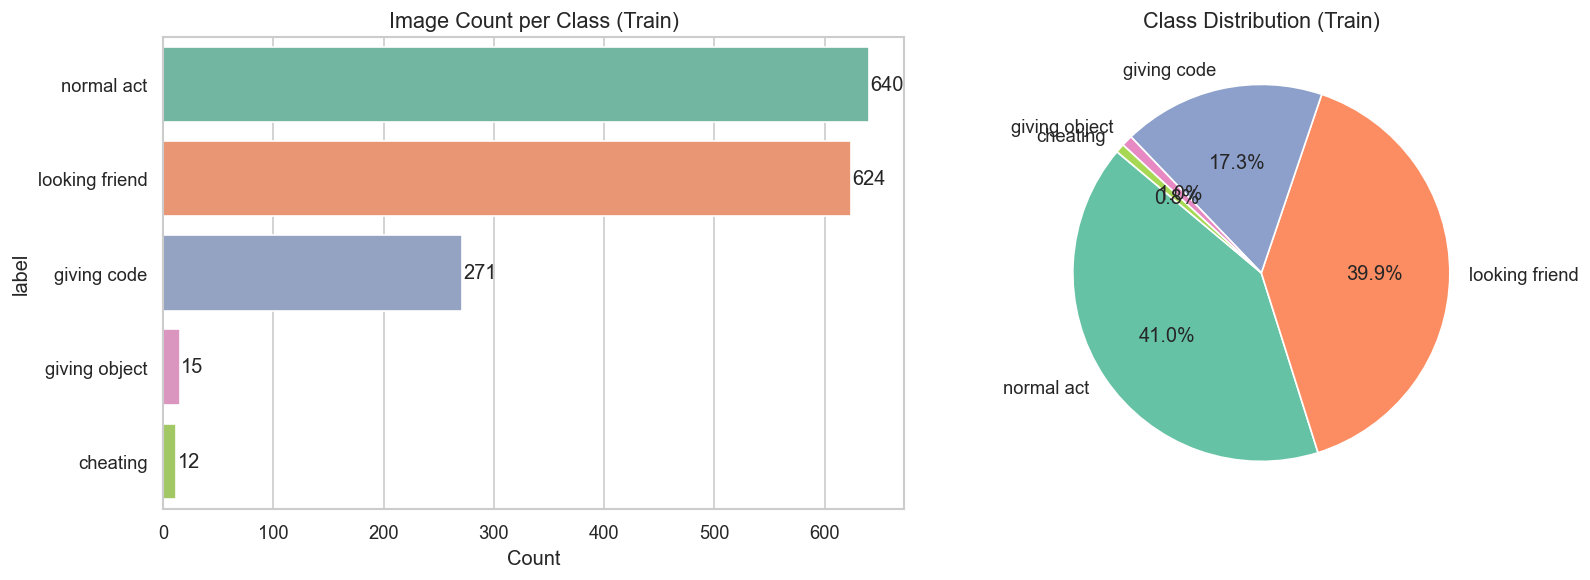


Class counts:
label
normal act        640
looking friend    624
giving code       271
giving object      15
cheating           12

Imbalance ratio (max/min): 53.33x


In [78]:
train_df = df[df['split'] == 'train'].copy()
class_counts = train_df['label'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
sns.barplot(x=class_counts.values, y=class_counts.index, palette='Set2', ax=axes[0])
axes[0].set_title('Image Count per Class (Train)', fontsize=13)
axes[0].set_xlabel('Count')
for i, v in enumerate(class_counts.values):
    axes[0].text(v + 1, i, str(v), va='center')

# Pie chart
axes[1].pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%',
            startangle=140, colors=sns.color_palette('Set2', len(class_counts)))
axes[1].set_title('Class Distribution (Train)', fontsize=13)

plt.tight_layout()
plt.show()

print("\nClass counts:")
print(class_counts.to_string())
print(f"\nImbalance ratio (max/min): {class_counts.max() / class_counts.min():.2f}x")

## 6. Train vs Test Split

Split distribution:
split
train    1562
test      496
Name: count, dtype: int64
Train ratio: 75.9%


/var/folders/6b/2xdghg1d1pbdb4bm239g47vh0000gn/T/ipykernel_7035/3062575319.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=split_counts.index, y=split_counts.values, palette='pastel')


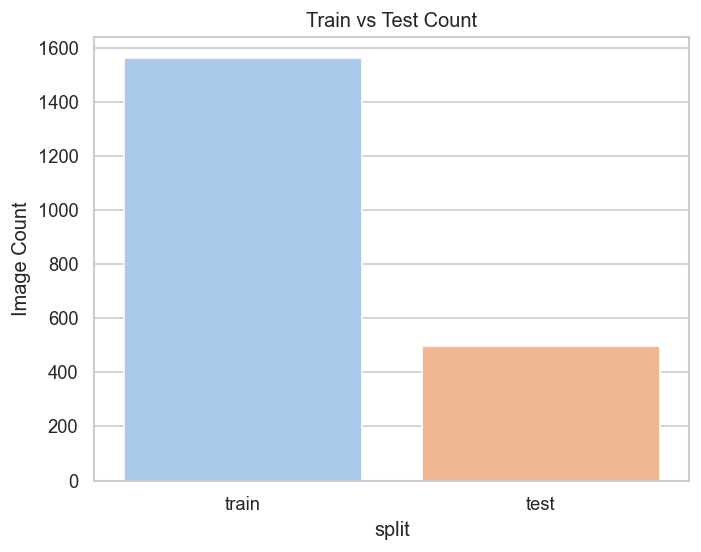

In [79]:
split_counts = df['split'].value_counts()
print("Split distribution:")
print(split_counts)
print(f"Train ratio: {split_counts['train'] / len(df) * 100:.1f}%")

sns.barplot(x=split_counts.index, y=split_counts.values, palette='pastel')
plt.title('Train vs Test Count')
plt.ylabel('Image Count')
plt.show()

## 7. Image Dimensions Analysis

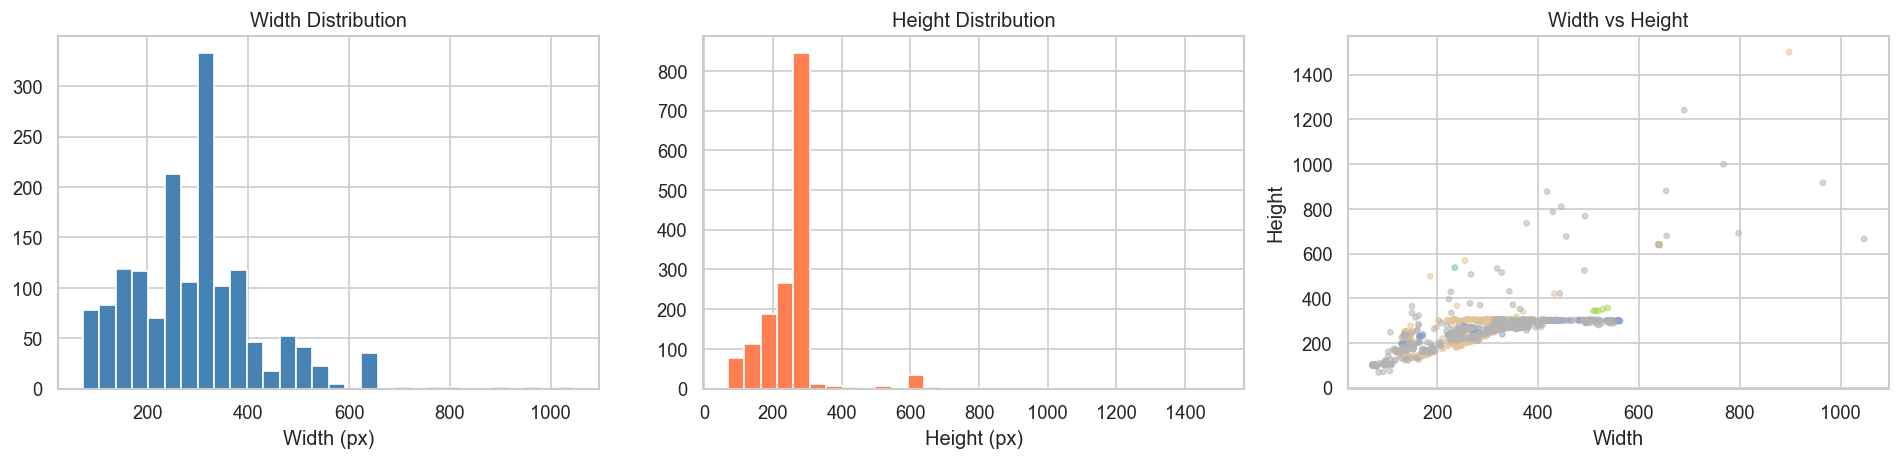

         width   height  aspect_ratio
count  1562.00  1562.00       1562.00
mean    291.76   263.67          1.10
std     126.10   104.57          0.26
min      72.00    68.00          0.37
25%     193.00   219.25          0.97
50%     298.50   270.00          1.08
75%     350.00   299.00          1.23
max    1047.00  1500.00          1.91


In [80]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(train_df['width'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Width Distribution')
axes[0].set_xlabel('Width (px)')

axes[1].hist(train_df['height'], bins=30, color='coral', edgecolor='white')
axes[1].set_title('Height Distribution')
axes[1].set_xlabel('Height (px)')

axes[2].scatter(train_df['width'], train_df['height'],
                c=[classes.index(l) for l in train_df['label']],
                cmap='Set2', alpha=0.5, s=10)
axes[2].set_title('Width vs Height')
axes[2].set_xlabel('Width')
axes[2].set_ylabel('Height')

plt.tight_layout()
plt.show()

print(train_df[['width', 'height', 'aspect_ratio']].describe().round(2))

## 8. Dimensions per Class

/var/folders/6b/2xdghg1d1pbdb4bm239g47vh0000gn/T/ipykernel_7035/3105030374.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train_df, x='label', y='width', palette='Set2', ax=axes[0])
/var/folders/6b/2xdghg1d1pbdb4bm239g47vh0000gn/T/ipykernel_7035/3105030374.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train_df, x='label', y='height', palette='Set2', ax=axes[1])


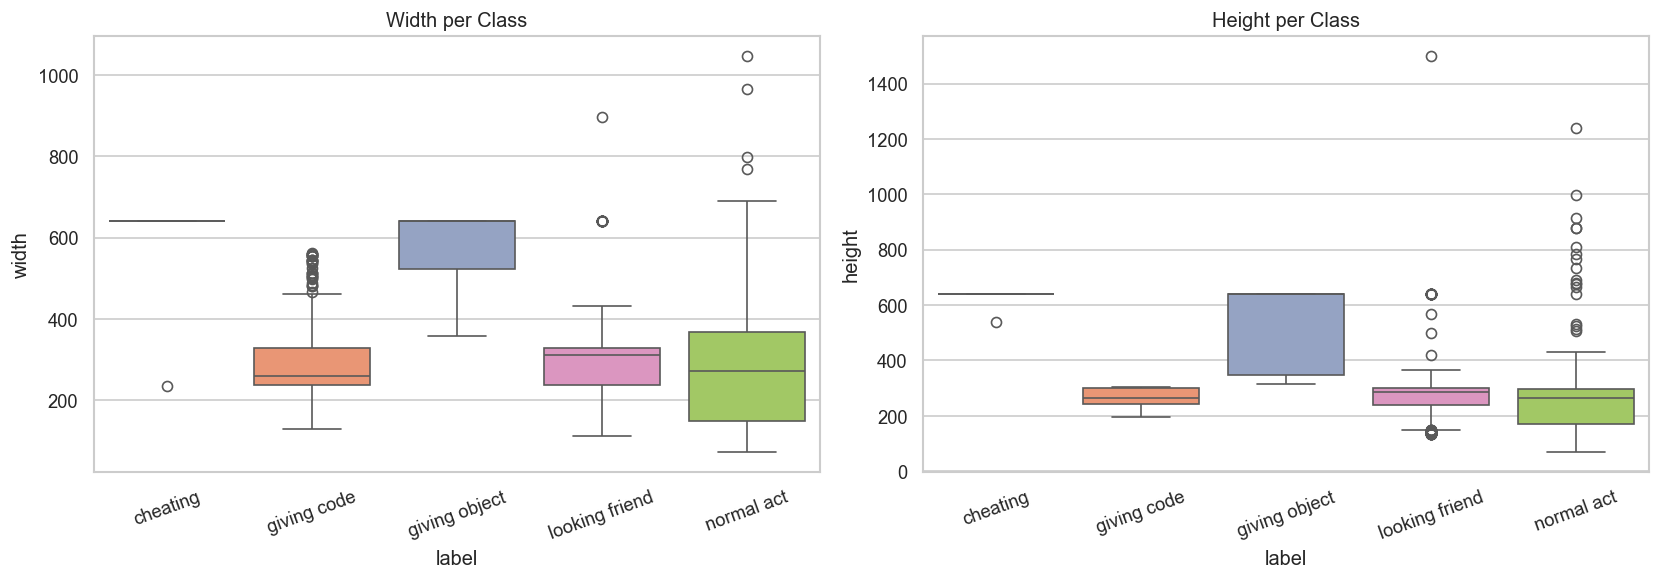

In [81]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=train_df, x='label', y='width', palette='Set2', ax=axes[0])
axes[0].set_title('Width per Class')
axes[0].tick_params(axis='x', rotation=20)

sns.boxplot(data=train_df, x='label', y='height', palette='Set2', ax=axes[1])
axes[1].set_title('Height per Class')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

## 9. Aspect Ratio Distribution

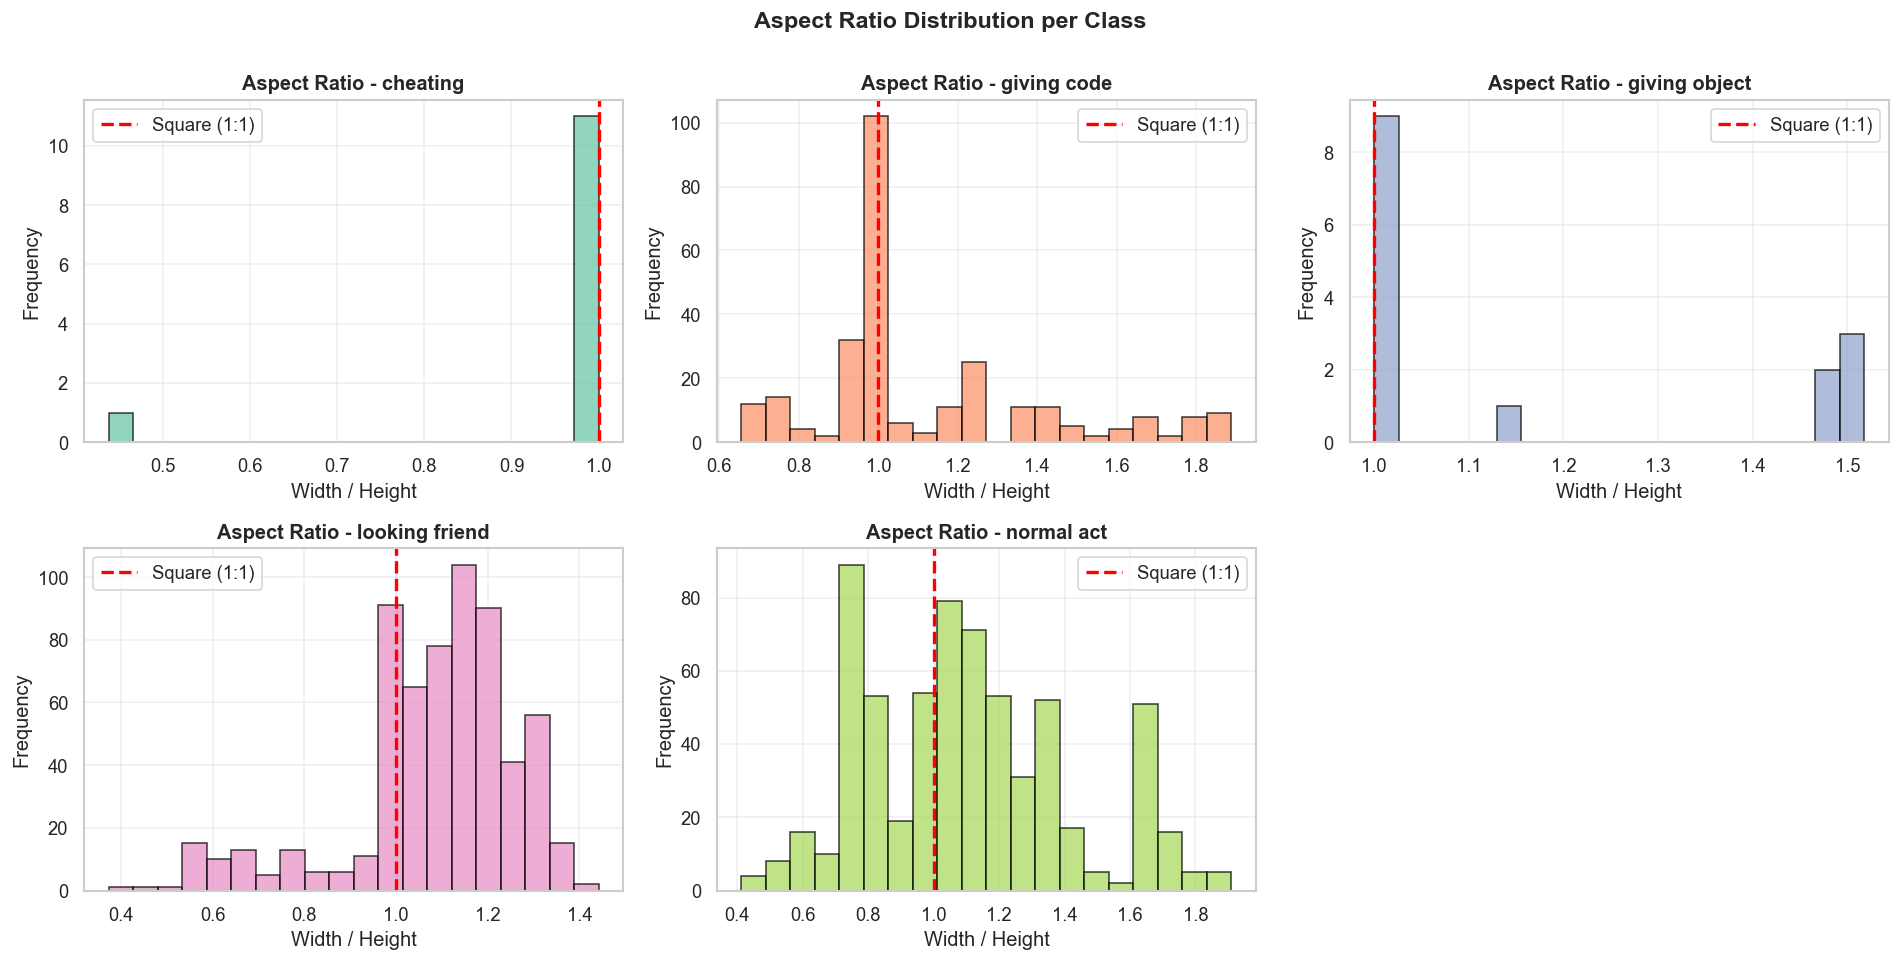

In [82]:
# Aspect ratio distribution for each class separately
import matplotlib.patches as mpatches
palette = sns.color_palette('Set2', n_colors=len(classes))

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for idx, cls in enumerate(classes):
    cls_data = train_df[train_df['label'] == cls]['aspect_ratio']
    axes[idx].hist(cls_data, bins=20, color=palette[idx], edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Aspect Ratio - {cls}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Width / Height')
    axes[idx].set_ylabel('Frequency')
    axes[idx].axvline(1.0, color='red', linestyle='--', linewidth=2, label='Square (1:1)')
    axes[idx].legend()
    axes[idx].grid(alpha=0.3)

# Hide the extra subplot
axes[5].axis('off')

plt.suptitle('Aspect Ratio Distribution per Class', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()


## 10. File Size Distribution

/var/folders/6b/2xdghg1d1pbdb4bm239g47vh0000gn/T/ipykernel_7035/292718197.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train_df, x='label', y='file_size_kb', palette='Set2', ax=axes[1])


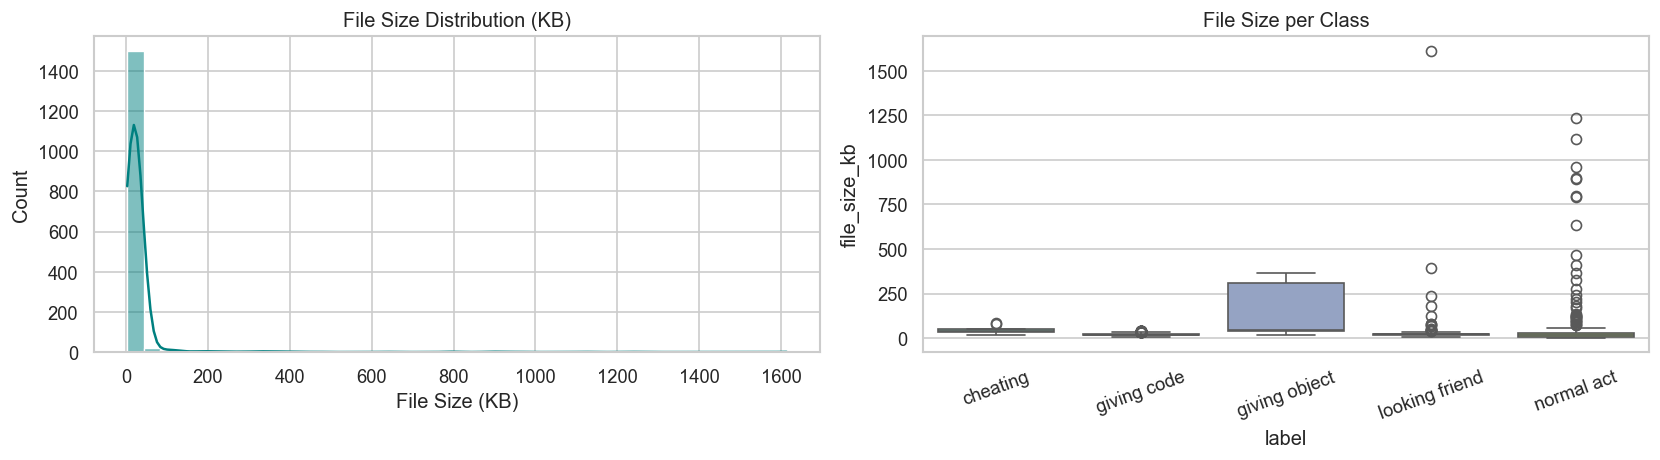

                count    mean     std    min    25%    50%     75%      max
label                                                                      
cheating         12.0   46.48   19.53  20.34  37.30  41.36   49.59    85.96
giving code     271.0   21.79    8.15   8.98  16.92  19.67   23.11    41.43
giving object    15.0  146.85  143.22  15.36  37.60  46.08  308.08   366.48
looking friend  624.0   24.89   67.06   5.19  15.32  22.36   25.36  1613.54
normal act      640.0   35.19  108.50   2.74   8.18  19.38   27.50  1236.84


In [83]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(train_df['file_size_kb'], bins=40, kde=True, color='teal', ax=axes[0])
axes[0].set_title('File Size Distribution (KB)')
axes[0].set_xlabel('File Size (KB)')

sns.boxplot(data=train_df, x='label', y='file_size_kb', palette='Set2', ax=axes[1])
axes[1].set_title('File Size per Class')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

print(train_df.groupby('label')['file_size_kb'].describe().round(2))

## 11. Color Mode & Unique Sizes Check

In [84]:
print("Color modes found:")
print(train_df['mode'].value_counts())

unique_sizes = train_df.groupby(['width', 'height']).size().reset_index(name='count')
print(f"\nUnique (width, height) combos in train: {len(unique_sizes)}")
print(unique_sizes.sort_values('count', ascending=False).head(10))

Color modes found:
mode
RGB     1508
RGBA      54
Name: count, dtype: int64

Unique (width, height) combos in train: 1096
      width  height  count
1087    640     640     33
0        72     101     27
2        73     102     18
405     245     243     18
1020    494     298     12
406     245     244      9
706     322     289      9
850     358     265      8
1019    494     297      8
657     318     297      8


## 12. Sample Images per Class

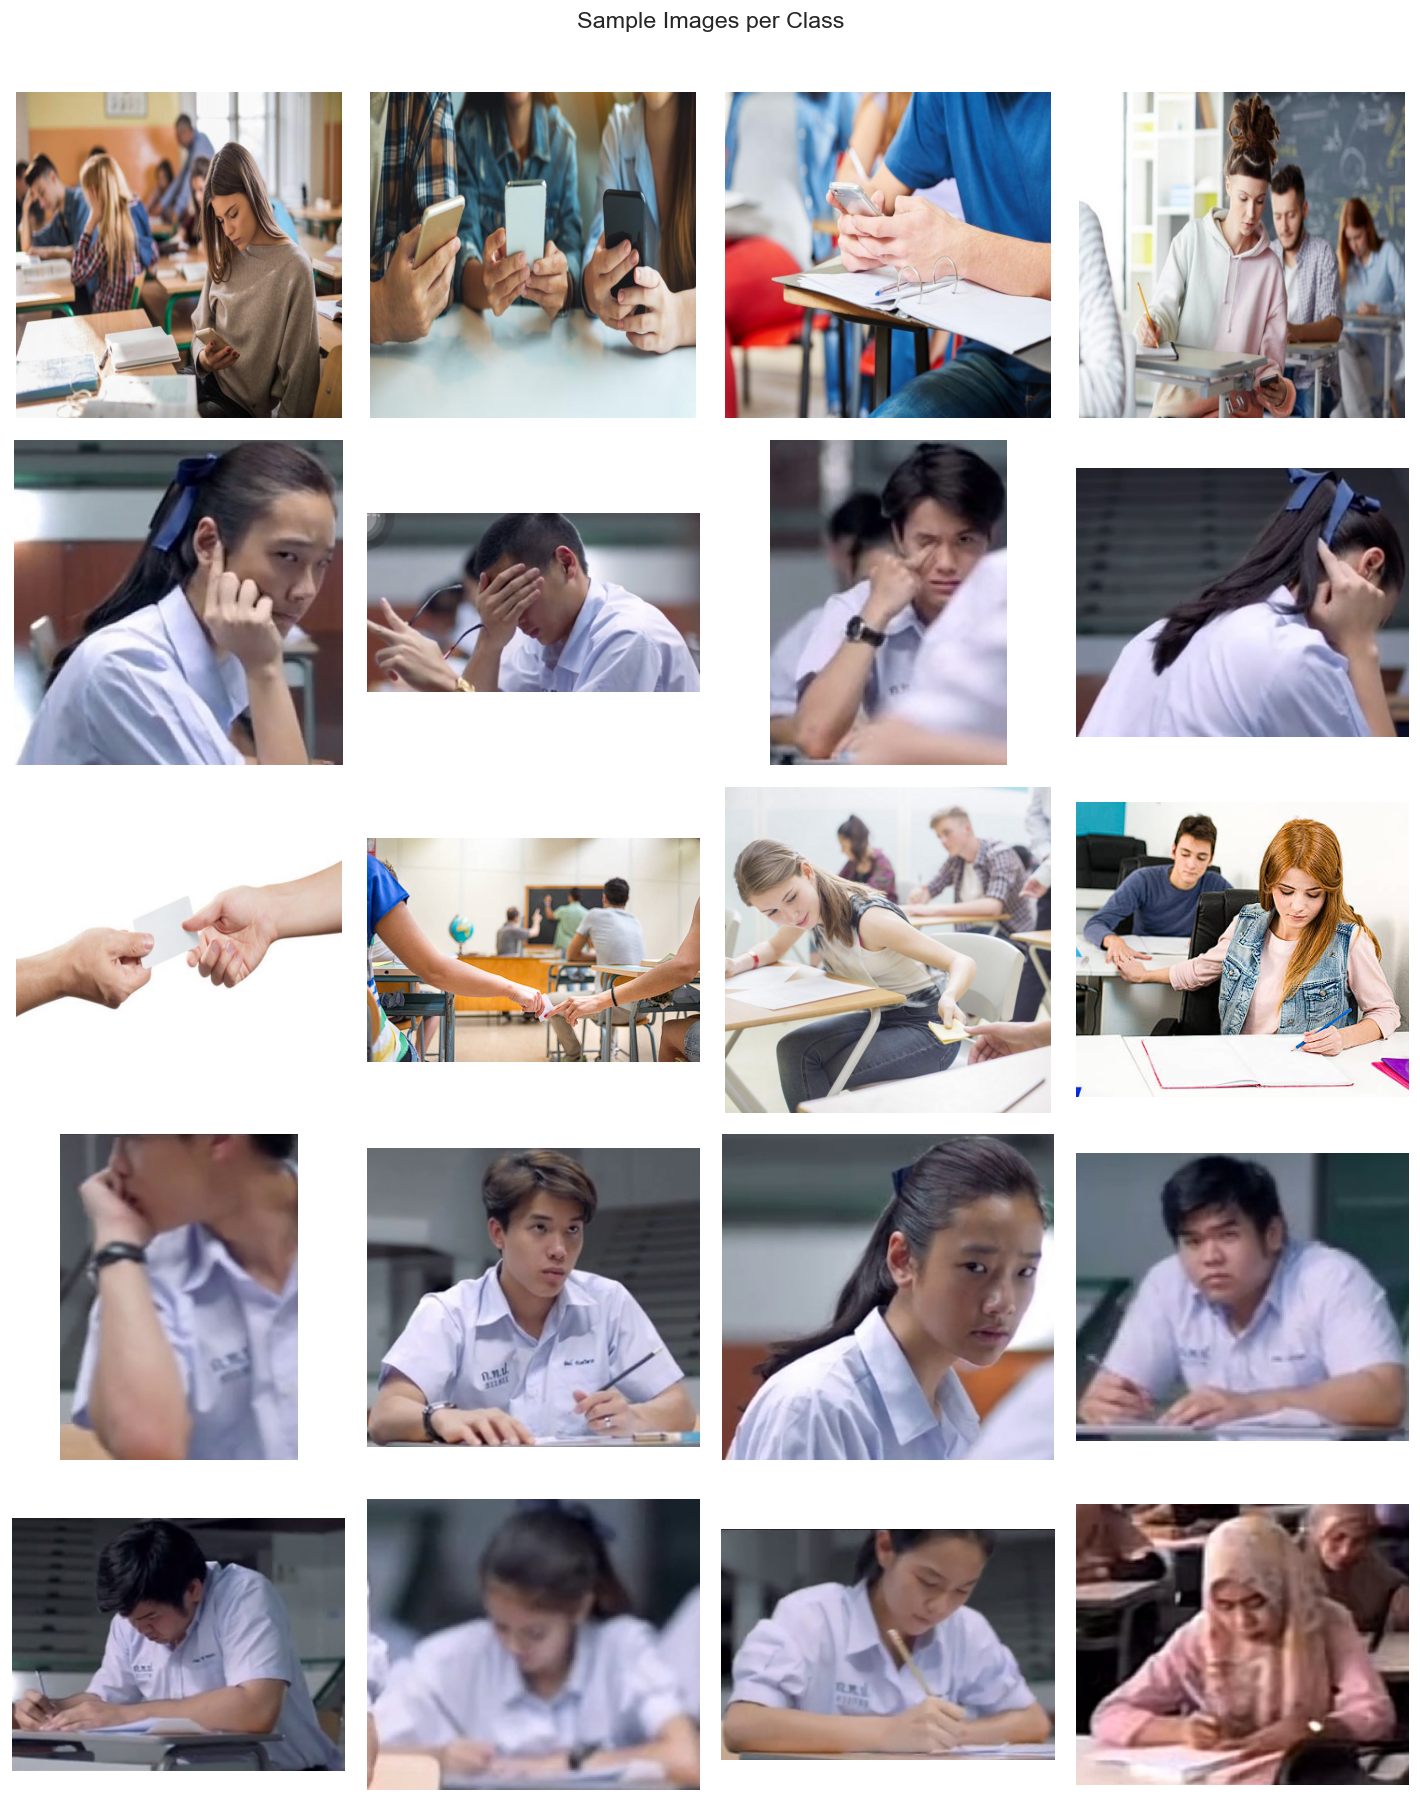

In [85]:
n_samples = 4
fig, axes = plt.subplots(len(classes), n_samples,
                         figsize=(n_samples * 3, len(classes) * 3))

for row, cls in enumerate(classes):
    cls_paths = train_df[train_df['label'] == cls]['path'].tolist()
    samples = random.sample(cls_paths, min(n_samples, len(cls_paths)))
    for col, path in enumerate(samples):
        img = mpimg.imread(path)
        axes[row][col].imshow(img)
        axes[row][col].axis('off')
        if col == 0:
            axes[row][col].set_ylabel(cls, fontsize=10, rotation=0,
                                      labelpad=70, va='center')

plt.suptitle('Sample Images per Class', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 13. Average Pixel Intensity per Class

/var/folders/6b/2xdghg1d1pbdb4bm239g47vh0000gn/T/ipykernel_7035/2879930930.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=bdf, x='label', y='brightness', palette='Set2')


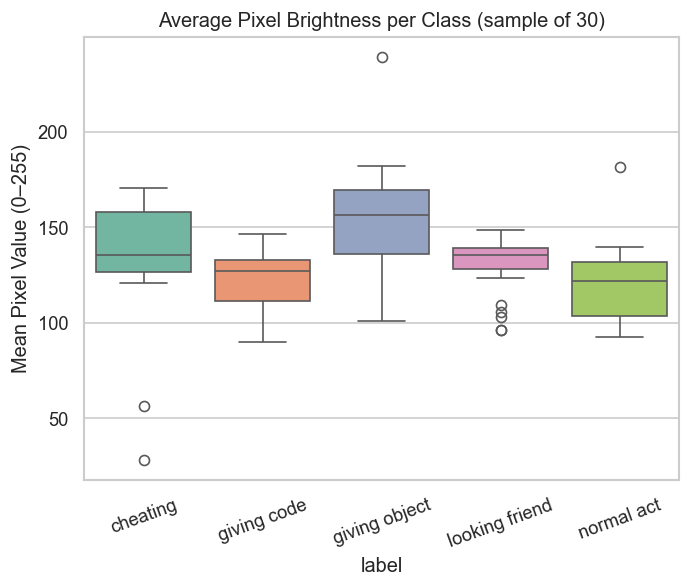

In [86]:
def avg_brightness(path, size=(64, 64)):
    try:
        img = Image.open(path).convert('RGB').resize(size)
        return np.array(img).mean()
    except:
        return None

# Sample 30 images per class for speed
brightness_records = []
for cls in classes:
    paths = train_df[train_df['label'] == cls]['path'].tolist()
    sample = random.sample(paths, min(30, len(paths)))
    for p in sample:
        b = avg_brightness(p)
        if b is not None:
            brightness_records.append({'label': cls, 'brightness': b})

bdf = pd.DataFrame(brightness_records)

sns.boxplot(data=bdf, x='label', y='brightness', palette='Set2')
plt.title('Average Pixel Brightness per Class (sample of 30)')
plt.ylabel('Mean Pixel Value (0–255)')
plt.xticks(rotation=20)
plt.show()

## 14. Average Color Channels per Class (R/G/B)

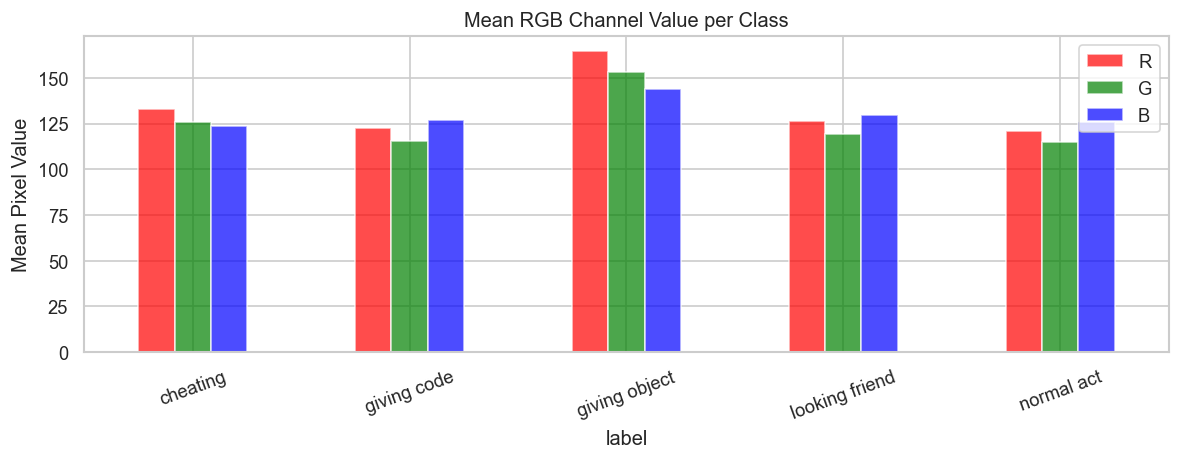

In [87]:
def avg_rgb(path, size=(64, 64)):
    try:
        img = np.array(Image.open(path).convert('RGB').resize(size))
        return img[:,:,0].mean(), img[:,:,1].mean(), img[:,:,2].mean()
    except:
        return None

rgb_records = []
for cls in classes:
    paths = train_df[train_df['label'] == cls]['path'].tolist()
    sample = random.sample(paths, min(30, len(paths)))
    for p in sample:
        result = avg_rgb(p)
        if result:
            r, g, b = result
            rgb_records.append({'label': cls, 'R': r, 'G': g, 'B': b})

rgb_df = pd.DataFrame(rgb_records)
rgb_means = rgb_df.groupby('label')[['R', 'G', 'B']].mean()

rgb_means.plot(kind='bar', color=['red', 'green', 'blue'], alpha=0.7,
               figsize=(10, 4))
plt.title('Mean RGB Channel Value per Class')
plt.ylabel('Mean Pixel Value')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 15. Correlation Heatmap (Numeric Features)

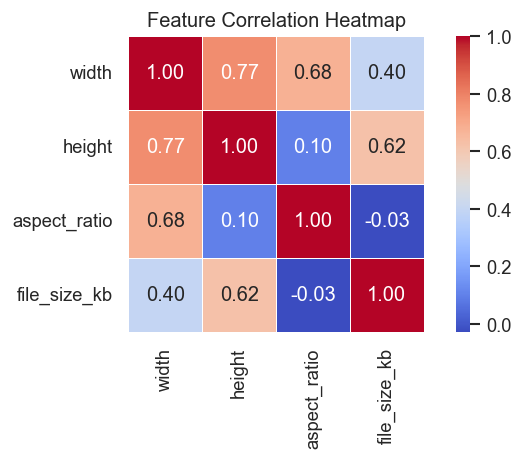

In [88]:
num_cols = ['width', 'height', 'aspect_ratio', 'file_size_kb']
corr = train_df[num_cols].corr()

plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

## 16. Summary Statistics

In [89]:
print("=" * 50)
print("DATASET SUMMARY")
print("=" * 50)
print(f"Total images      : {len(df)}")
print(f"Train images      : {len(train_df)}")
print(f"Test images       : {len(df[df['split']=='test'])}")
print(f"Number of classes : {len(classes)}")
print(f"Classes           : {classes}")
print()
print("Class distribution (train):")
print(train_df['label'].value_counts().to_string())
print()
print(f"Image widths  : {train_df['width'].min()}–{train_df['width'].max()} px (mean: {train_df['width'].mean():.0f})")
print(f"Image heights : {train_df['height'].min()}–{train_df['height'].max()} px (mean: {train_df['height'].mean():.0f})")
print(f"Color modes   : {train_df['mode'].unique().tolist()}")
print(f"Avg file size : {train_df['file_size_kb'].mean():.1f} KB")
print()
imbalance = class_counts.max() / class_counts.min()
if imbalance > 1.5:
    print(f"⚠️  Class imbalance detected ({imbalance:.2f}x). Consider augmentation or weighted loss.")
else:
    print(f"✅ Classes are fairly balanced ({imbalance:.2f}x ratio).")

DATASET SUMMARY
Total images      : 2058
Train images      : 1562
Test images       : 496
Number of classes : 5
Classes           : ['cheating', 'giving code', 'giving object', 'looking friend', 'normal act']

Class distribution (train):
label
normal act        640
looking friend    624
giving code       271
giving object      15
cheating           12

Image widths  : 72–1047 px (mean: 292)
Image heights : 68–1500 px (mean: 264)
Color modes   : ['RGB', 'RGBA']
Avg file size : 29.9 KB

⚠️  Class imbalance detected (53.33x). Consider augmentation or weighted loss.
